In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [17]:
def remove_practice(data_path):
    exp_data = pd.read_csv(data_path, sep=',')
    data_without_prac = exp_data[exp_data['condition'] == 'main_exp']
    data_without_prac = data_without_prac[data_without_prac['outcome'] != 'missed']
    return data_without_prac
#data_without_prac = remove_practice("C:/Users\sarah/two-armed-bandit/two-armed-bandit/pilot_data/sub-17_task-two-armed-bandit.csv")

In [7]:
def optimal_choice_prob(data_without_prac):
    optimal_choices = 0
    chosen_stim = "none"
    for index, trial in data_without_prac.iterrows():
       if trial["chosen_stim_name"] == "stimuli/slotA_up.png" and trial["position_changed"] == 0:
          chosen_stim = "left"
       elif trial["chosen_stim_name"] == "stimuli/slotB_up.png" and trial["position_changed"] == 1:
          chosen_stim = "left"
       elif trial["chosen_stim_name"] == "stimuli/slotA_up.png" and trial["position_changed"] == 1:
          chosen_stim = "right"
       elif trial["chosen_stim_name"] == "stimuli/slotB_up.png" and trial["position_changed"] == 0:
          chosen_stim = "right"

       if chosen_stim == trial["rational_choice"]:
          optimal_choices +=1
    optimal_choices = optimal_choices / (len(data_without_prac)-1)
    return round(optimal_choices*100,2)
    print(f"the subject chose in {round(optimal_choices*100,2)}% of trials the optimal stimulus")


In [26]:
# fallunterscheidung zwischen salient wins and just wins
def win_stay_loose_shift(data_without_prac): 
    data_without_prac['outcome'] = [int(outcome) for outcome in data_without_prac['outcome']]
    wins = data_without_prac[data_without_prac['outcome'] == 1]
    losses = data_without_prac[data_without_prac['outcome'] == 0]
    salient_wins = wins[wins['saliency']]
    non_salient_wins = wins[wins['saliency'] == False]
    #print(len(non_salient_wins))
    win_stay = 0
    win_stay_saliency = 0
    loose_stay = 0
    for index in range(len(data_without_prac) - 1): # Iterate over indices up to the second last row
        current_trial = data_without_prac.iloc[index]
        next_trial = data_without_prac.iloc[index + 1]
        #win and saliency
        if current_trial["outcome"] == 1 and current_trial["saliency"]:
            if current_trial["chosen_stim_name"] == next_trial["chosen_stim_name"]:
                win_stay_saliency += 1
        # win but no saliency
        elif current_trial["outcome"] == 1 and current_trial["saliency"]==False:
            if current_trial["chosen_stim_name"] == next_trial["chosen_stim_name"]:
                win_stay += 1
        # loose
        elif current_trial["outcome"] == 0 and current_trial["chosen_stim_name"] == next_trial["chosen_stim_name"]:
            loose_stay += 1
    #print(win_stay)
    win_stay = round((win_stay/(len(non_salient_wins)))*100)
    win_stay_saliency = round((win_stay_saliency/(len(salient_wins)))*100)
    loose_stay = round((loose_stay/(len(losses)))*100)
    #print(salient_wins)
    #print(f"new subject")
    #print(f"in {win_stay_saliency}% of cases the subject stayed after a salient win")
    #print(f"in {win_stay}% of cases the subject stayed after a win")
    #print(f"in {100-loose_stay}% of cases the subject switched after losing")
    return win_stay_saliency, win_stay, 100-loose_stay
    
#win_stay_loose_shift(data_without_prac)

In [44]:
# Directory containing the CSV files
data_dir = 'C:/Users\sarah/two-armed-bandit/two-armed-bandit/pilot_data/neu'
opt_choice_list = []
win_stay_list = []
loose_switch_list = []
win_stay_saliency_list = []

# Iterate over CSV files in the directory
for file_name in os.listdir(data_dir):
    if file_name.endswith('.csv'):
        file_path = os.path.join(data_dir, file_name)
        # Read the CSV file into a DataFrame and append to the list
        data = remove_practice(file_path)
        win_stay_saliency, win_stay, loose_stay = win_stay_loose_shift(data)
        opt_choice_list.append(optimal_choice_prob(data))
        win_stay_list.append(win_stay)
        win_stay_saliency_list.append(win_stay_saliency)
        loose_switch_list.append(100-loose_stay)


basic_analysis = [[1,2,3,4,5],win_stay_saliency_list, win_stay_list, loose_switch_list, opt_choice_list]
df = pd.DataFrame(basic_analysis)
df = df.transpose()
df.columns = ['Subject ID', 'Salient Win Stay Prob (in%)','Win Stay Prob (in %)', 'Loose Shift Prob (in %)', '%Optimal Choice']
df

,Subject ID,Salient Win Stay Prob (in%),Win Stay Prob (in %),Loose Shift Prob (in %),%Optimal Choice
0,1.0,93.0,100.0,51.0,68.24
1,2.0,96.0,93.0,59.0,55.41
2,3.0,62.0,54.0,58.0,56.76
3,4.0,52.0,50.0,47.0,49.32
4,5.0,93.0,71.0,53.0,63.19


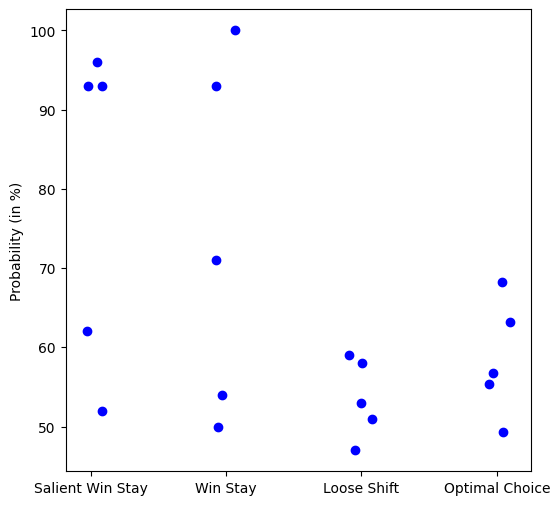

In [56]:
# Melt the DataFrame to long format
df_melted = df.melt(id_vars=['Subject ID'], 
                    value_vars=['Salient Win Stay Prob (in%)', 'Win Stay Prob (in %)', 'Loose Shift Prob (in %)', '%Optimal Choice'],
                    var_name='Condition', 
                    value_name='Probability')

# Define the correct order of conditions
condition_order = ['Salient Win Stay', 'Win Stay', 'Loose Shift', 'Optimal Choice']

# Map original condition names to new ones
condition_mapping = {
    'Salient Win Stay Prob (in%)': 'Salient Win Stay', 
    'Win Stay Prob (in %)': 'Win Stay', 
    'Loose Shift Prob (in %)': 'Loose Shift',
    '%Optimal Choice': 'Optimal Choice'
}
df_melted['Condition'] = df_melted['Condition'].map(condition_mapping)

# Ensure all conditions are correctly mapped
if df_melted['Condition'].isnull().any():
    print("There are unmapped conditions in the data.")
    print(df_melted[df_melted['Condition'].isnull()])

# Map conditions to numerical codes
condition_map = {condition: i for i, condition in enumerate(condition_order)}
df_melted['Condition Code'] = df_melted['Condition'].map(condition_map)

# Check if any conditions are unmapped
if df_melted['Condition Code'].isnull().any():
    print("There are conditions without numerical codes.")
    print(df_melted[df_melted['Condition Code'].isnull()])

# Add jitter to the x-axis positions
jitter_strength = 0.1
df_melted['Jittered Condition'] = df_melted['Condition Code'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(df_melted))

# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust the figure size
plt.scatter(df_melted['Jittered Condition'], df_melted['Probability'], color='b')

# Set x-ticks and labels
plt.xticks(range(len(condition_order)), condition_order)

plt.ylabel('Probability (in %)')

plt.show()

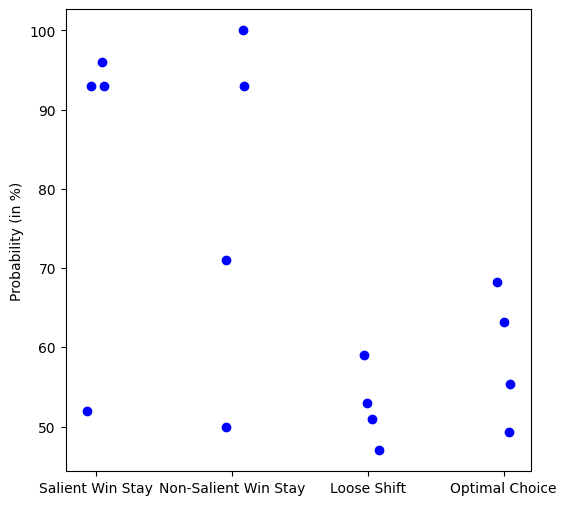

In [43]:
# Melt the DataFrame to long format
df_melted = df.melt(id_vars=['Subject ID'], 
                    value_vars=['Salient Win Stay Prob (in%)', 'Win Stay Prob (in %)', 'Loose Shift Prob (in %)', '%Optimal Choice'],
                    var_name='Condition', 
                    value_name='Probability')

# Define the correct order of conditions and map them to numerical codes
condition_order = ['Salient Win-Stay', 'Non-Salient Win-Stay', 'Loose-Shift', 'Optimal Choice']
condition_map = {condition: i for i, condition in enumerate(condition_order)}

# Rename conditions in df_melted to match the condition_order
df_melted['Condition'] = df_melted['Condition'].map({
    'Salient Win Stay Prob (in%)': 'Salient Win Stay', 
    'Win Stay Prob (in %)': 'Non-Salient Win Stay', 
    'Loose Shift Prob (in %)': 'Loose Shift',
    '%Optimal Choice': 'Optimal Choice'
})

# Apply the correct condition map to get numerical codes
df_melted['Condition Code'] = df_melted['Condition'].map(condition_map)

# Add jitter to the x-axis positions
jitter_strength = 0.1
df_melted['Jittered Condition'] = df_melted['Condition Code'] + np.random.uniform(-jitter_strength, jitter_strength, size=len(df_melted))

# Create the scatter plot
plt.figure(figsize=(6, 6))  # Adjust the figure size
plt.scatter(df_melted['Jittered Condition'], df_melted['Probability'], color='b')

# Set x-ticks and labels
plt.xticks(range(len(condition_order)), condition_order)

plt.ylabel('Probability (in %)')

plt.show()

In [6]:
# wins in general
def win_stay_loose_shift_all(data_without_prac):  
    data_without_prac['outcome'] = [int(outcome) for outcome in data_without_prac['outcome']]
    wins = data_without_prac[data_without_prac['outcome'] == 1]
    losses = data_without_prac[data_without_prac['outcome'] == 0]
    win_stay = 0
    loose_stay = 0
    for index in range(len(data_without_prac) - 1): # Iterate over indices up to the second last row
        current_trial = data_without_prac.iloc[index]
        next_trial = data_without_prac.iloc[index + 1]
        #win 
        if current_trial["outcome"] == 1:
            if current_trial["chosen_stim_name"] == next_trial["chosen_stim_name"]:
                win_stay += 1
               
        # loose
        elif (current_trial["outcome"] == 0) and (current_trial["chosen_stim_name"] == next_trial["chosen_stim_name"]):
            loose_stay += 1
    win_stay = (win_stay/(len(wins)-1))*100
    loose_stay = (loose_stay/(len(losses)-1))*100
    #print(salient_wins)
    return win_stay, loose_stay
    print(f"new subject")
    print(f"in {round(win_stay,2)}% of cases the subject stayed after a win")
    print(f"in {round(100-loose_stay,2)}% of cases the subject switched after losing")
#weird_data = remove_practice('C:/Users\sarah/two-armed-bandit/two-armed-bandit/pilot_data/sub-17_task-two-armed-bandit.csv')
#win_stay_loose_shift_all(weird_data)   